<div style="text-align: center;">

  <!-- Logotipo -->
  <img src="img/LogoUesc.png" alt="UESC" style="width: 60px; display: block; margin: 0 auto 5px auto;">

  <!-- Cabeçalho -->
  <div style="font-size: 20px;"><strong>UNIVERSIDADE ESTADUAL DE SANTA CRUZ - UESC</strong></div>
  <div style="font-size: 18px;">DEPARTAMENTO DE ENGENHARIAS E COMPUTAÇÃO</div>
  <div style="font-size: 18px;">ENGENHARIA QUÍMICA</div>

  <hr style="margin: 20px 0; border: 1px solid #0074B7;">

  <!-- Título do Trabalho -->
  <div style="font-size: 22px; font-weight: bold; margin-bottom: 10px;">Introdução a Controle de Processos</div>
  <div style="font-size: 20px; font-weight: bold; margin-bottom: 10px;">Cálculo Computacional da Altura de um Tanque Drenado por Gravidade em Função do Tempo</div>

  <!-- Autor e orientador -->
  <div style="font-size: 18px;">Prof. Dr. E.R.Edwards</div>

  <!-- Data -->
<!-- <div style="font-size: 16px; margin-top: 15px;">Ilhéus - BA, Abril de 2025</div> -->
</div>

__Exercício — Modelagem Dinâmica de um Tanque__

Considere um tanque de seção transversal constante $A$, no qual a altura do líquido é representada por $h(t)$. O tanque recebe uma vazão de entrada variável $q_{in}(t)$ e possui uma válvula de saída na parte inferior.

A vazão de saída é governada pela relação hidráulica da válvula:

$$q_{out}(t) = C_v \sqrt{h(t)}$$


onde $C_v $ é o coeficiente da válvula.


- Utilizando o princípio de conservação de massa, deduza a equação diferencial que descreve a dinâmica da altura do líquido no tanque.

-  A partir da equação diferencial obtida, derive uma forma computacional (discretizada) que permita calcular numericamente a evolução da altura
$h(t)$ ao longo do tempo.

- Explique o significado físico de cada termo presente na equação resultante.


<img src="img/fig-tanque-balanco.png" alt="UESC" style="width: 400px; display: block; margin: 0 auto 5px auto;">
<p style="text-align: center;"><strong>Figura: Modelo dinâmico de um Tanque.</strong></p>

#### solução:

1 -Balanço de Massa.

$$q_{in}(t) - q_{out}(t) = \frac{dV}{dt}$$

Sabendo-se que: $V = A.h$ e sendo $A$=cte o único termo que varia com o tempo é $h(t)$. Então, temos:

$$q_{in}(t) - q_{out}(t) = \frac{d(Ah(t))}{dt}$$
$$q_{in}(t) - q_{out}(t) = A\frac{dh(t)}{dt}...\text{Eq.1}$$

Agora, podemos pegar a expressão [1] e dividir por $A$.
$$\frac{dh(t)}{dt} = \frac{1}{A}[q_{in}(t) - q_{out}(t)] ...\text{Eq.2}$$

onde o termo $q_{out}$ é a função de altura do líquido no tanque:

$$q_{out}(t) = c_v \sqrt{h}...\text{Eq.3}$$

$$\frac{dh(t)}{dt} = \frac{1}{A}[q_{in}(t) - c_v \sqrt{h}] ...\text{Eq.4}$$

A expressão 4 será usada para os cálculos computacionais.

2 - Cálculo computacional

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [10]:
# Dados de entrada.
Cv = 0.1 # [m^3.min/s] -> constnte da válvula 
A  = 1.0 # [m^2] -> área do tanque.

In [11]:
# Expressões para o cálculo.
def qin(t):
    return 0.15

def deriv(h, t):
    I = qin(t)/A  - Cv*np.sqrt(h)/A
    return I
    
IC =  [0.0] # Condições iniciais (Initial conditions-IC)

# Estabelecendo o tempo de simulação.
start = 0
stop = 200.0
step = 201

t = np.linspace(start, stop, step)
h = odeint(deriv, IC, t)

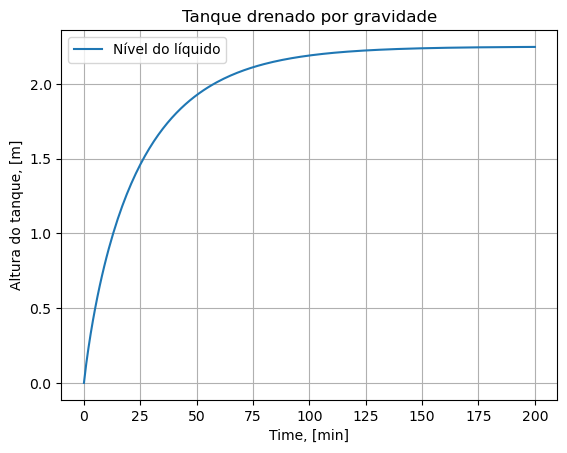

: 

In [ ]:
# Condições de saída.
plt.plot(t, h)
plt.xlabel('Time, [min]')
plt.ylabel('Altura do tanque, [m]')
plt.title('Tanque drenado por gravidade')
plt.legend(['Nível do líquido'])
plt.grid()
plt.show()